# **Meshlands - Temperature**
This notebook presents temperature- and energy-related results and analysis. It is organized as:
- Temperature,
- Ice coverage,
- Focus and variable comparisons.

## **Initial Set Up-related**

### Imports

In [17]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Function Definitions

In [18]:
# Overall: creates a new local mapping function that doesn't use basemap
def quick_map(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    creates a new local mapping function that does not use a basemap
    '''

    # Makes 2 subplots: one for map, one for zonal average next to it
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects the case mask data to plot coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,lat,cyclic_data,transform=ccrs.PlateCarree())
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=20) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=20)

    # Sets cm to the cmap
    cm = plt.get_cmap()
   
    # Overall: adds hatching for significance
    # If a p-value is specified, add 
    if p:

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_sig, cyclic_lons = add_cyclic_point(sigmask,coord=lon)

        # Creates a meshgrid using cyclic longitude and latitude coordinates
        CLN, CLT = np.meshgrid(cyclic_lons,lat)

        # Only puts the hatches where the sigmask is >0.5
        sigmask = np.where(cyclic_sig>p,1.0,np.nan)
        sigmask2 = np.ma.masked_where(cyclic_sig > p, sigmask)

        # Masks out insignificant latitude data
        lat_sig = np.ma.masked_where(cyclic_sig>p,CLT)

        # Masks out NaN latitude data
        lat_sig = np.ma.masked_where(np.isnan(cyclic_sig),lat_sig)

        # Masks out insignificant longitude data
        lon_sig = np.ma.masked_where(cyclic_sig>p,CLN)

        # Masks out NaN longitude data
        lon_sig = np.ma.masked_where(np.isnan(cyclic_sig),lon_sig)

        # Scatters markers
        hatch = ax.scatter(lon_sig,lat_sig,s=sigmask2,marker='x',#s=2,
                           c=[0.6, 0.6, 0.6],alpha=0.8,transform=ccrs.PlateCarree(),)

    # Add hatching for oceans
    #ax.contourf(xc_cyc, yc_cyc, mask_cyc, levels=[-0.5, 0.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree())

    # Add points for ocean cells
    #ax.scatter(xc_cyc[mask_cyc == 0], yc_cyc[mask_cyc == 0], marker='.', color='black', s=0.5, transform=ccrs.PlateCarree())

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # Sets the alpha value
    ax.patch.set_alpha(0.0)

    # Add a line at the bottom of the plot to draw the separation with the following plot
    line = plt.Line2D([0.1, 0.9], [0.12, 0.12], transform=fig.transFigure, color='black')
    fig.add_artist(line)
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

##########

# Overall : calculates the global mean, ocean mean and land mean
def mean(ds_case,mask,var):
    '''
    Calculates the global, ocean and land mean of a given variable for a given configuration.

    Args:
        ds_case (xarray): dictionnary containing lat and lon dimensions.
        mask (list): representation of continental distribution, with value 1 if land and value 0 if ocean.
        var (str): name of the variable that needs to be averaged.

    Returns:
        gm (float OR array): global mean (can be an array if ds_case contains others dimensions).
        lm (float OR array): land mean (can be an array if ds_case contains others dimensions).
        om (float OR array): ocean mean (can be an array if ds_case contains others dimensions).
    '''

    # Collects the datas to plot the surface temperature
    mapdata = (ds_case[var].mean('year'))
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case[var].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

### Path Definitions

In [19]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [20]:
# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','ICEFRAC','T','hyai','LHFLX','SHFLX','PRECC','PRECL']

### Dictionary Definitions

In [21]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [22]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


## **Surface Temperature (radiative)**

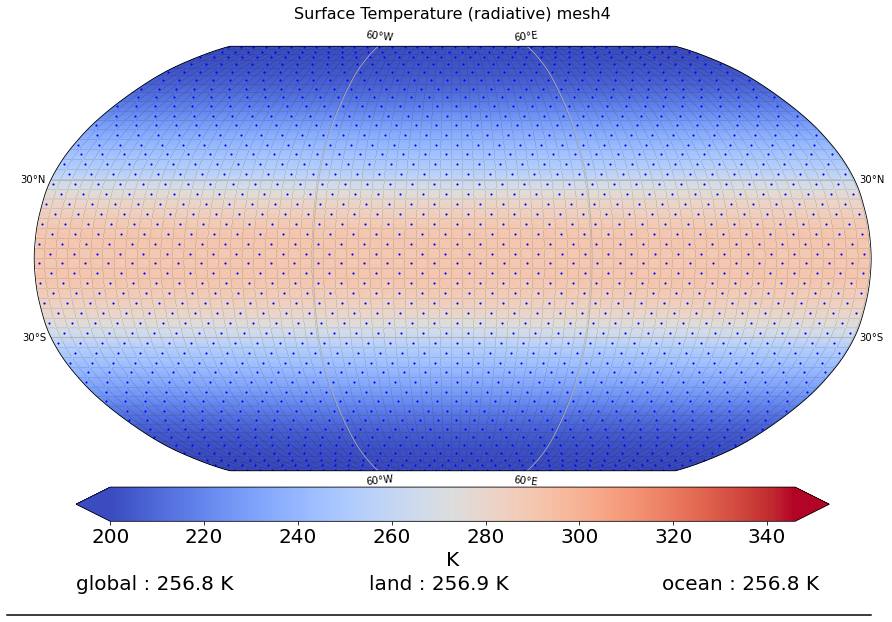

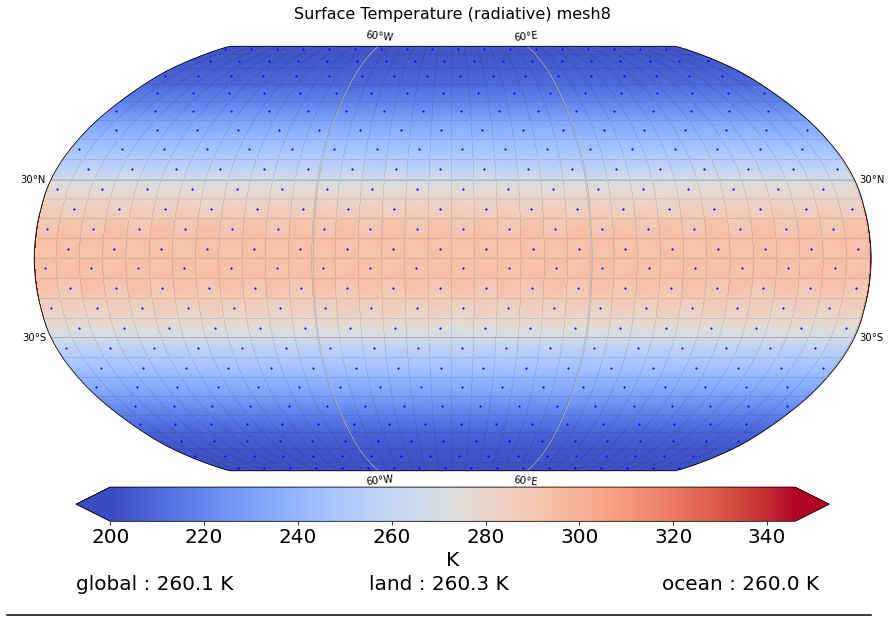

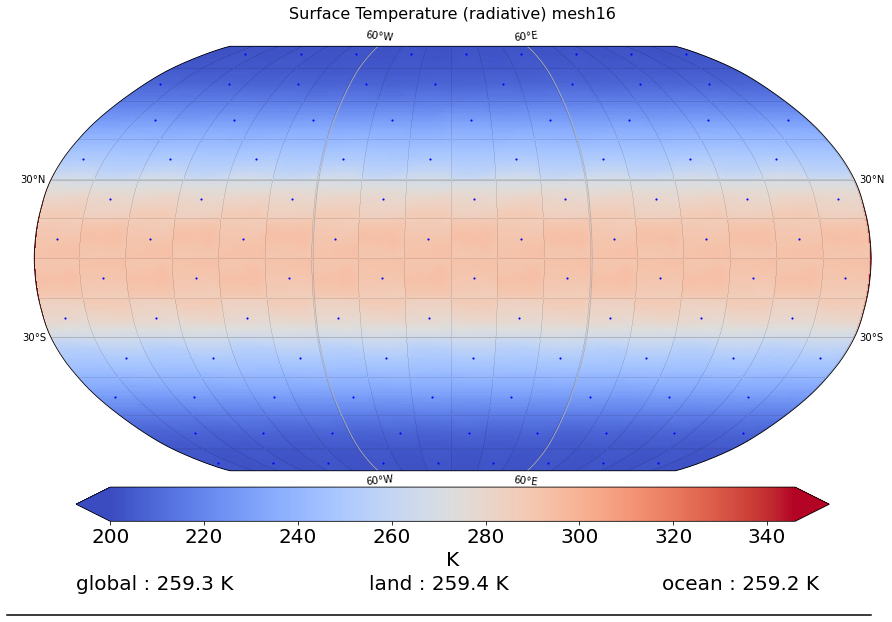

In [23]:
# Overall: plots separately the surface temperature for all meshes, using the quick_map function previously defined

for case in config:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Collects the datas to plot the surface temperature
    mapdata = (ds_case['TS'].mean('year'))
    
    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values

    # Uses the mean function
    gm, lm, om = mean(ds_case, mask, 'TS')
    
    # Gets the min and max value of mapdata (unused here but can be used for the clim)
    T_min = mapdata.min().values
    T_max = mapdata.max().values
    clim=[273-73.,273+73.]
    
    # Sets the plot's title
    ttl = 'Surface Temperature (radiative) %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('coolwarm')

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='K',
              cmap=cmap,clim=clim,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')
    
    # Annotates the subplot with the global mean, land mean and ocean mean
    ax.text(0.05, -0.28, 'global : %1.1f K'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.4, -0.28, 'land : %1.1f K'%lm, transform=ax.transAxes, fontsize=20)
    ax.text(0.75, -0.28, 'ocean : %1.1f K'%om, transform=ax.transAxes, fontsize=20)

    ax.gridlines(draw_labels=True,xlocs=[-60,60],ylocs=[-30,30])

    plt.show()
    plt.close()

## **Temperature Evolution with Altitude**

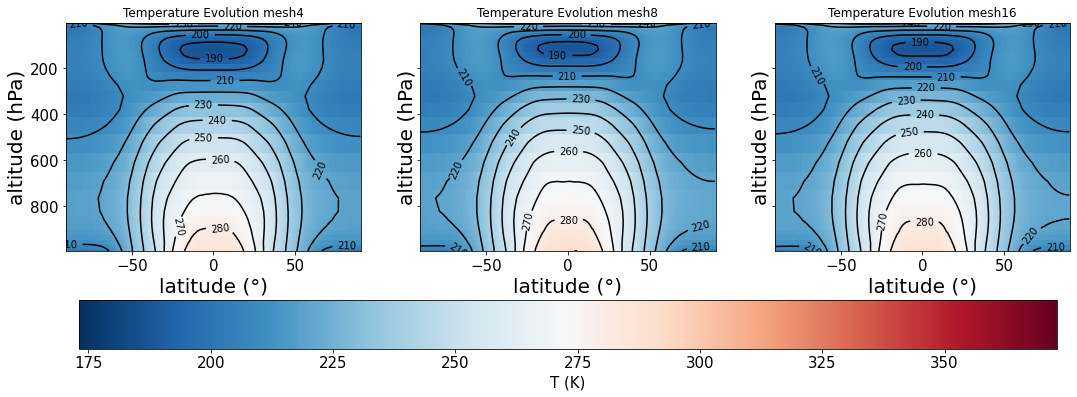

In [24]:
# Overall: draws the temperature evolution with altitude, based on a zonal average

# Creates an empty list to contain the case and the map data
plot_data = []
for case in config :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    T = ds_case['T'].mean('year').mean('lon')
    plot_data.append((case,T))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (case, T) in zip(axes, plot_data):
    lat = T['lat']
    lev = T['lev']

    # Draws contour at 0 °C
    cs = ax.contour(lat, lev, T, levels=10, linestyles=None, colors='k')
    ax.clabel(cs, fmt="%d", fontsize=10, inline=True)
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, T, cmap='RdBu_r', vmin=273-100, vmax=273+100, shading='auto')
    
    ax.set_title(f'Temperature Evolution {case}')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('T (K)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

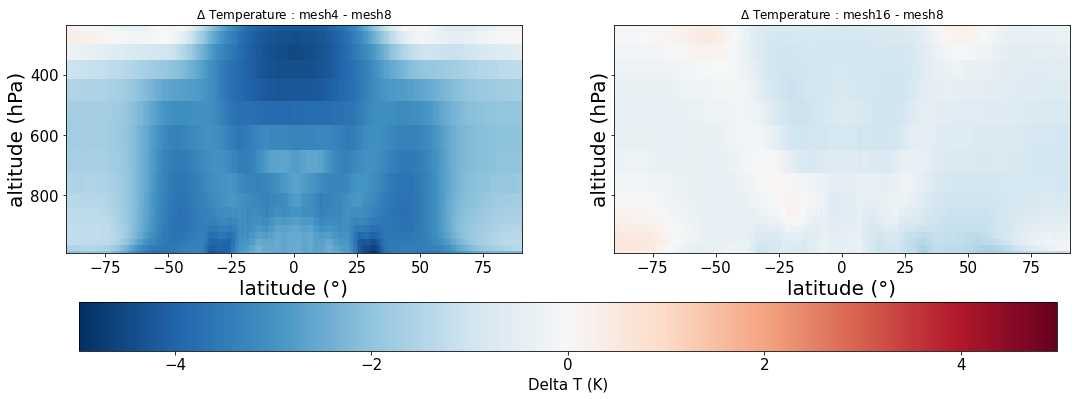

In [25]:
# Overall: plots the temperature vertical evolution differences with a reference case

# Calculates the data for the reference case
ds8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds8['T'].mean('year').mean('lon')

# Creates an empty list to contain the data
plot_data = []
for case in ['mesh4','mesh16'] :
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    T = ds_case['T'].mean('year').mean('lon') - ref
    plot_data.append((case,T))

# Shared colour limits for the same scale across all plots
# Calculates the min and max value of all Q for the colorbar
vmin = min(float(T.min().values) for (case, T) in plot_data)
vmax = max(float(T.max().values) for (case, T) in plot_data)
lim = max(abs(vmin),abs(vmax))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, (case, T) in zip(axes, plot_data):
    lat = T['lat']
    lev = T['lev'][15:]
    
    # Draws the colormap
    im = ax.pcolormesh(lat, lev, T[15:,:], cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    
    ax.set_title(f'$\Delta$ Temperature : {case} - mesh8')
    ax.set_xlabel('latitude (°)',fontsize=20)
    ax.set_ylabel('altitude (hPa)',fontsize=20)
    ax.tick_params(labelsize=15)
    # Reverts the y-axis
    ax.set_ylim(lev.max().values, lev.min().values)

# Manages the colorbar
cb = fig.colorbar(im, ax=axes, orientation='horizontal')
cb.set_label('Delta T (K)',fontsize=15)
cb.ax.tick_params(labelsize=15)

plt.show()
plt.close()

# **Ice**

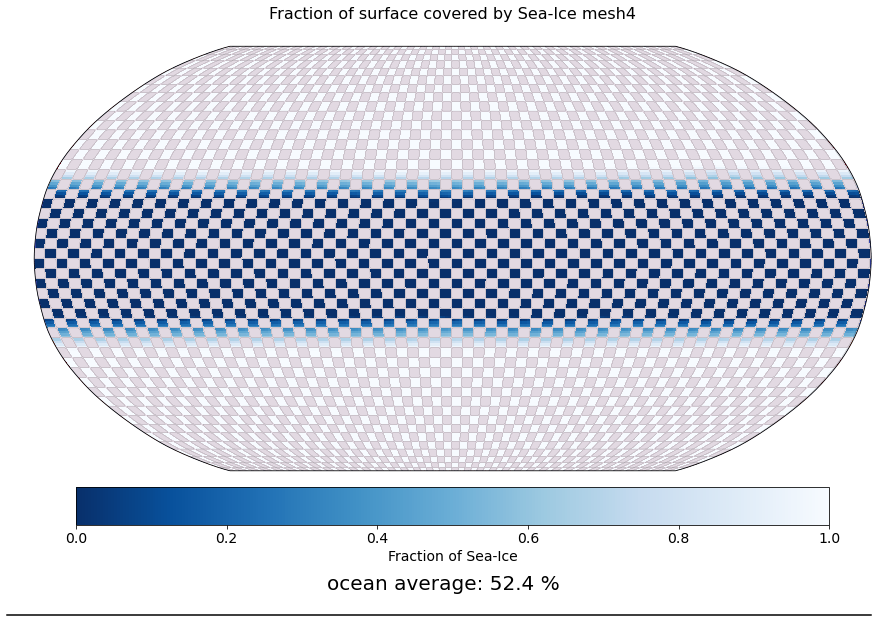

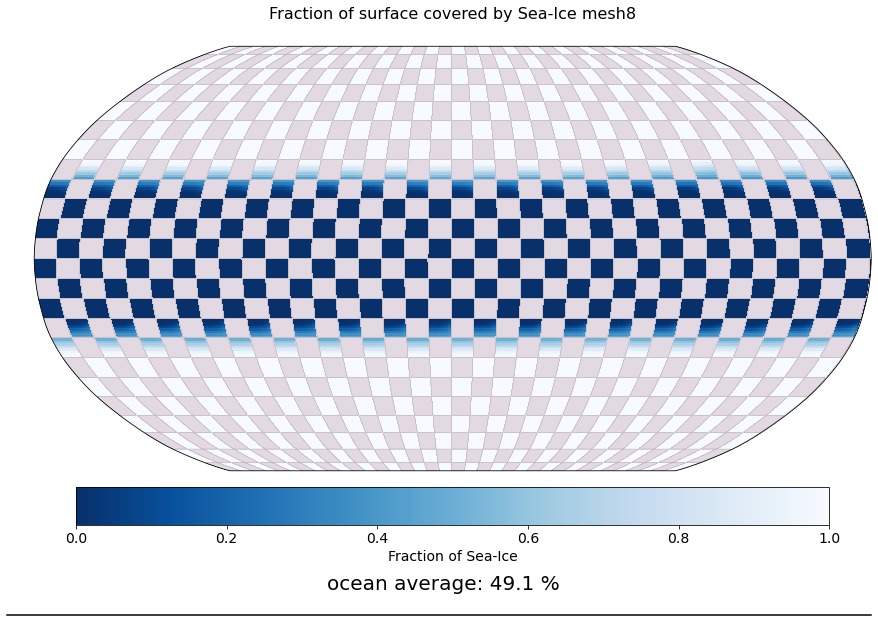

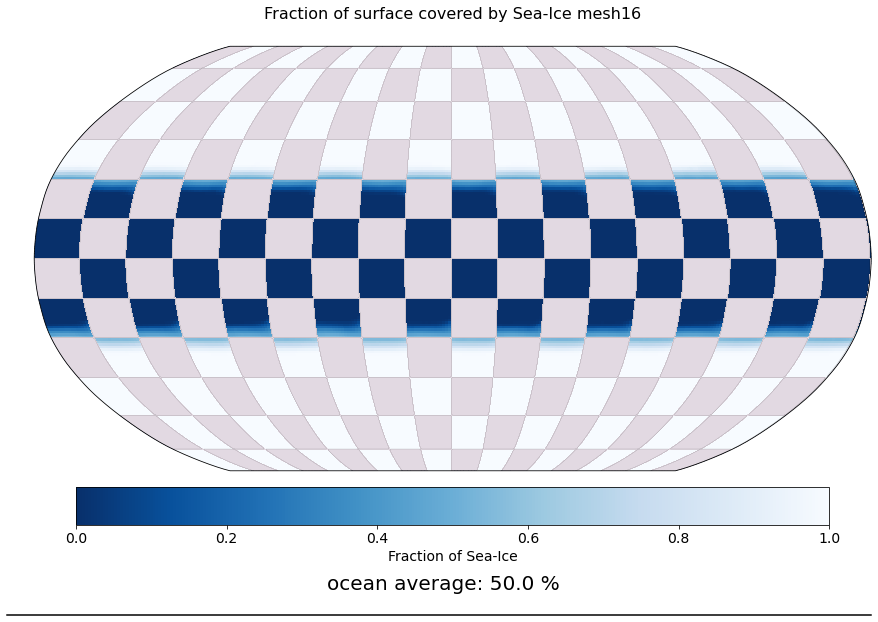

In [26]:
# Overall: creates a map plot of each of the simulation cases
for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['ICEFRAC'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    # Uses the mean function to calculate the ocean mean
    _, _, om = mean(ds_case, mask, 'ICEFRAC')
    om_prct = 100 * om
    
    # Sets the plot's title
    ttl = 'Fraction of surface covered by Sea-Ice %s'%(case)

    fig = plt.figure(figsize=(15,15))
    
    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects the case mask data to plot coastlines
    xc_cyc = np.concatenate([mesh_dict[case]["xc"], mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh_dict[case]["yc"], mesh_dict[case]["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,mapdata.lat,cyclic_data,transform=ccrs.PlateCarree())

    # cmap
    plt.set_cmap('Blues_r')
    plt.title(ttl,fontsize=16,y=1.05)
    plt.cm.ScalarMappable.set_clim(cs,vmin = 0,vmax = 1)

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=None,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=14) 
    cbar.set_label('Fraction of Sea-Ice',fontsize=14)

    # Sets cm to the cmap
    cm = plt.get_cmap()
    
    # Cover land parts that are not concerned by sea-ice
    land = np.ma.masked_where(mask_cyc == 0, mask_cyc)
    ax.pcolormesh(xc_cyc,yc_cyc,land,transform=ccrs.PlateCarree(),cmap='twilight',shading='auto')

    # Add a line at the bottom of the plot to draw the separation with the following plot
    line = plt.Line2D([0.1, 0.9], [0.12, 0.12], transform=fig.transFigure, color='black')
    fig.add_artist(line)

    # Annotates the subplot with the ocean mean
    ax.text(0.35, -0.28, 'ocean average: %1.1f %%'%om_prct, transform=ax.transAxes, fontsize=20)
    
    plt.show()
    plt.close()

# **Focus**

## Temperature correlations

In [27]:
def get_mapdata(ds, row):
    '''
    Calculates a different mapdata based on the row concerned by the plot (only used is the next cell)
    '''
    if row == 0:
        return ds['TS'].mean('year')
    elif row == 1:
        return ds['LHFLX'].mean('year')

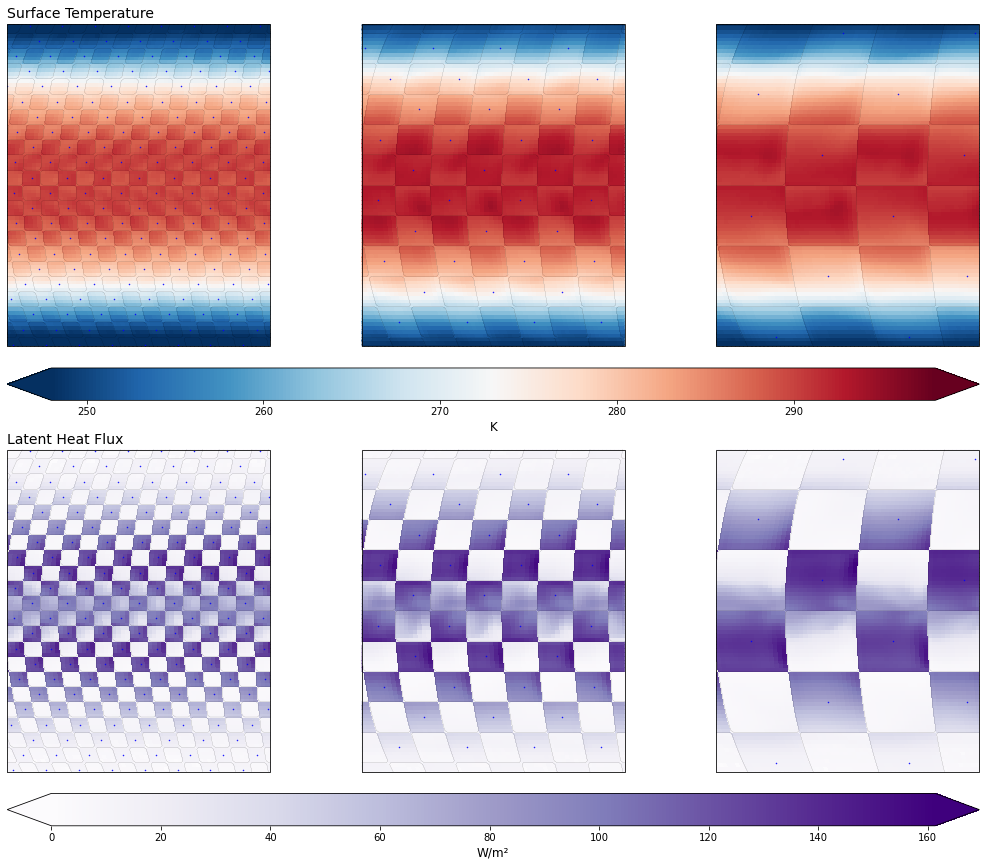

In [28]:
# Overall: compares the subtropics distribution of the surface temperature and the surface latent heat flux

fig = plt.figure(figsize=(18, 15))

# Organizes the subplots of the figure
gs = fig.add_gridspec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1, 0.1, 1, 0.1])
ax_map_list = [[fig.add_subplot(gs[2*i, j], projection=ccrs.Robinson()) for j in range(3)] for i in range(2)]
cs_list = [None, None]

row_titles = ['Surface Temperature',
              'Latent Heat Flux']

row_units = ['K',
             'W/m²']

# Calculates the min and max values for each row of plots to draw a unique colorbar for each row
vmin_list, vmax_list = [], []
for row in range(2):
    all_vals = []
    for case in ['mesh4','mesh8','mesh16']:
        ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
        mapdata = get_mapdata(ds_case, row)
        all_vals.append(float(mapdata.min()))
        all_vals.append(float(mapdata.max()))
    vmax = max(abs(min(all_vals)), abs(max(all_vals)))
    vmin_list.append(0)
    vmax_list.append(vmax)

# Associates a title to each row
for row in range(2):
    ax_map_list[row][0].set_title(row_titles[row], fontsize=14, loc='left', pad=6)
    
for (i, case) in enumerate(['mesh4','mesh8','mesh16']):
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Collects the mask case to differentiate oceans
    ocean_mask = (mesh_dict[case]['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers, lat_centers = [], []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        dlon = mesh_dict[case]['xc'][0, 1] - mesh_dict[case]['xc'][0, 0]
        dlat = mesh_dict[case]['yc'][1, 0] - mesh_dict[case]['yc'][0, 0]
        lon_centers.append(mesh_dict[case]['xc'][0, 0] + x * dlon)
        lat_centers.append(mesh_dict[case]['yc'][0, 0] + y * dlat)

    # Collects the case mask data to plot coastlines
    xc_cyc   = np.concatenate([mesh_dict[case]["xc"],   mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc   = np.concatenate([mesh_dict[case]["yc"],   mesh_dict[case]["yc"][:, :1]],        axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]],       axis=1)

    # Plots the mapdata for each row
    for row in range(2):
        # Collects data using the function defined previously
        mapdata = get_mapdata(ds_case, row)

        # Sets the subplot
        ax = ax_map_list[row][i]

        # Draws the coastlines
        ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
        # Sets the view to be focused over the subtropics
        ax.set_extent([-120, -50, -40, 40], crs=ccrs.PlateCarree())

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

        # Plots the data as a coloured mesh
        if row == 0:
            cs = ax.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data, cmap='RdBu_r', vmin=273-25., vmax=273+25., transform=ccrs.PlateCarree())
        else :
            cs = ax.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data, cmap='Purples', vmin=vmin_list[row], vmax=vmax_list[row], transform=ccrs.PlateCarree())
        
        cs_list[row] = cs

        # Draws a blue dot to highlight ocean cells
        ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=1, transform=ccrs.PlateCarree())

# Manages colorbar positioning and display
fig.canvas.draw()
for row in range(2):
    ax_ref  = ax_map_list[row][0]
    ax_last = ax_map_list[row][-1]
    pos0 = ax_ref.get_position()
    pos1 = ax_last.get_position()
    cax = fig.add_axes([pos0.x0, pos0.y0 - 0.05, pos1.x1 - pos0.x0, 0.03])
    cb = fig.colorbar(cs_list[row], cax=cax, orientation='horizontal', extend='both')
    cb.set_label(row_units[row], fontsize=12)
    cb.ax.tick_params(labelsize=10)
    
plt.show()
plt.close()

In [29]:
def get_mapdata(ds, row):
    '''
    Calculates a different mapdata based on the row concerned by the plot (only used is the next cell)
    '''
    if row == 0:
        return ds['TS'].mean('year')
    elif row == 1:
        return (ds['PRECC'].mean('year') + ds['PRECL'].mean('year')) *86400*365.25*1000

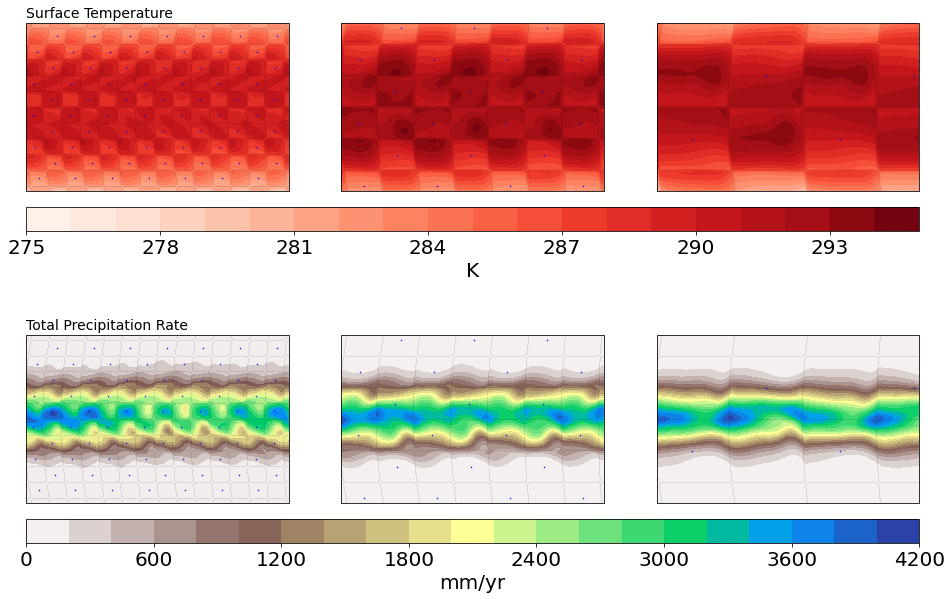

In [30]:
# Overall: compares the subtropics distribution of the surface temperature and the total precipitation rate

fig = plt.figure(figsize=(16, 11))

# Organizes the subplots of the figure
gs = fig.add_gridspec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1, 0.1, 1, 0.1])
ax_map_list = [[fig.add_subplot(gs[2*i, j], projection=ccrs.Robinson()) for j in range(3)] for i in range(2)]
cs_list = [None, None]

row_titles = ['Surface Temperature',
              'Total Precipitation Rate']

row_units = ['K',
             'mm/yr']

# Calculates the min and max values for each row of plots to draw a unique colorbar for each row
vmin_list, vmax_list = [], []
for row in range(2):
    all_vals = []
    for case in ['mesh4','mesh8','mesh16']:
        ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
        mapdata = get_mapdata(ds_case, row)
        all_vals.append(float(mapdata.min()))
        all_vals.append(float(mapdata.max()))
    vmax = max(abs(min(all_vals)), abs(max(all_vals)))
    vmin_list.append(0)
    vmax_list.append(vmax)

# Associates a title to each row
for row in range(2):
    ax_map_list[row][0].set_title(row_titles[row], fontsize=14, loc='left', pad=6)
    
for (i, case) in enumerate(['mesh4','mesh8','mesh16']):
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    
    # Collects the mask case to differentiate oceans
    ocean_mask = (mesh_dict[case]['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers, lat_centers = [], []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        dlon = mesh_dict[case]['xc'][0, 1] - mesh_dict[case]['xc'][0, 0]
        dlat = mesh_dict[case]['yc'][1, 0] - mesh_dict[case]['yc'][0, 0]
        lon_centers.append(mesh_dict[case]['xc'][0, 0] + x * dlon)
        lat_centers.append(mesh_dict[case]['yc'][0, 0] + y * dlat)

    # Collects the case mask data to plot coastlines
    xc_cyc   = np.concatenate([mesh_dict[case]["xc"],   mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc   = np.concatenate([mesh_dict[case]["yc"],   mesh_dict[case]["yc"][:, :1]],        axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]],       axis=1)

    # Plots the mapdata for each row
    for row in range(2):
        # Collects data using the function defined previously
        mapdata = get_mapdata(ds_case, row)

        # Sets the subplot
        ax = ax_map_list[row][i]

        # Draws the coastlines
        ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
        # Sets the view to be focused over the very low latitudes
        ax.set_extent([-120, -50, -20, 20], crs=ccrs.PlateCarree())

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

        # Plots the data as a coloured mesh
        if row == 0:
            vmin, vmax = 275., 295.
            levels = np.linspace(vmin, vmax, 21)
            cs = ax.contourf(cyclic_lons, mapdata.lat, cyclic_data, levels=levels, cmap ='Reds', transform=ccrs.PlateCarree())    
        else :
            cs = ax.contourf(cyclic_lons, mapdata.lat, cyclic_data, levels=20, cmap='terrain_r', transform=ccrs.PlateCarree())
        cs_list[row] = cs

        # Draws blue dots at the center of each ocean
        ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=1, transform=ccrs.PlateCarree())

# Manages positioning and display of colorbars
fig.canvas.draw()
for row in range(2):
    ax_ref  = ax_map_list[row][0]
    ax_last = ax_map_list[row][-1]
    pos0 = ax_ref.get_position()
    pos1 = ax_last.get_position()
    cax = fig.add_axes([pos0.x0, pos0.y0 - 0.05, pos1.x1 - pos0.x0, 0.03])
    cb = fig.colorbar(cs_list[row], cax=cax, orientation='horizontal')
    cb.set_label(row_units[row], fontsize=20)
    cb.ax.tick_params(labelsize=20)

plt.show()
plt.close()

## Ice Coverage (Subtropics)

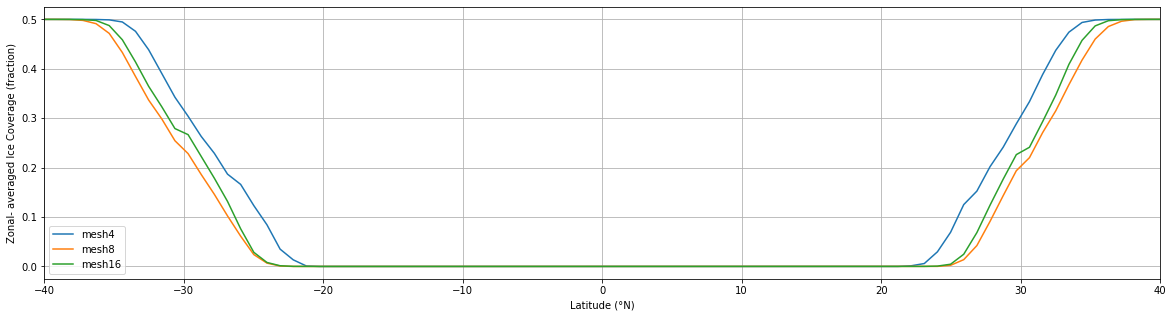

In [31]:
# Overall: plots the longitude average sea-ice coverage for each plot to compare the ice extent

plt.figure(figsize=(20,5))

for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['ICEFRAC'].mean('year').mean('lon')

    plt.plot(mapdata.lat,mapdata,label=case)

plt.grid()
plt.xlabel('Latitude (°N)')
plt.xlim([-40,40])
plt.ylabel('Zonal- averaged Ice Coverage (fraction)')
plt.legend()

plt.show()
plt.close()